# Bước 0: Thiết lập Môi trường và Tải Dữ liệu

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.6 MB/s eta 0:00:00


**1. Giải nẻn file**

In [2]:
# Giải nén file .tar.gz
# cờ 'z' cho gzip, 'x' cho extract, 'v' cho verbose (hiển thị file), 'f' cho file
!tar -xzvf hwu.tar.gz

print("\nGiải nén hoàn tất! Các file .csv đã sẵn sàng.")

hwu/
hwu/categories.json
hwu/train_5.csv
hwu/train_10.csv
hwu/val.csv
hwu/test.csv
hwu/train.csv

Giải nén hoàn tất! Các file .csv đã sẵn sàng.


**2. Tải dữ liệu**

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# Tải dữ liệu từ các file csv
df_train = pd.read_csv('hwu/train.csv', sep=',', header=None, names=['text', 'intent'])
df_val = pd.read_csv('hwu/val.csv', sep=',', header=None, names=['text', 'intent'])
df_test = pd.read_csv('hwu/test.csv', sep=',', header=None, names=['text', 'intent'])\

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)

print("\n5 dòng đầu của tập train:")
df_train.head()

Train shape: (8955, 2)
Validation shape: (1077, 2)
Test shape: (1077, 2)

5 dòng đầu của tập train:


,text,intent
0,text,category
1,what alarms do i have set right now,alarm_query
2,checkout today alarm of meeting,alarm_query
3,report alarm settings,alarm_query
4,see see for me the alarms that you have set to...,alarm_query


**3. Tiền xử lý Nhãn (LabelEncoder)**

In [4]:
# Khởi tạo LabelEncoder
label_encoder = LabelEncoder()

# Gộp tất cả intent từ cả 3 tập để đảm bảo encoder "nhìn thấy" tất cả các lớp
all_intents = pd.concat([df_train['intent'], df_val['intent'], df_test['intent']])
label_encoder.fit(all_intents)

# Transform các nhãn
y_train_encoded = label_encoder.transform(df_train['intent'])
y_val_encoded = label_encoder.transform(df_val['intent'])
y_test_encoded = label_encoder.transform(df_test['intent'])

# Lấy số lượng lớp (num_classes)
num_classes = len(label_encoder.classes_)

print(f"Số lượng lớp (num_classes): {num_classes}")
print("\nVí dụ về mã hóa nhãn:")
print(f"'{df_train['intent'][0]}'  => {y_train_encoded[0]}")
print(f"'{df_train['intent'][1]}'  => {y_train_encoded[1]}")

Số lượng lớp (num_classes): 65

Ví dụ về mã hóa nhãn:
'category'  => 9
'alarm_query'  => 0


# Nhiệm vụ 1: Pipeline TF-IDF + Logistic Regression

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

print("--- Bắt đầu Nhiệm vụ 1: TF-IDF + Logistic Regression ---")

# 1. Tạo pipeline
tfidf_lr_pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000),  # Giới hạn 5000 từ vựng quan trọng nhất
    LogisticRegression(max_iter=1000, random_state=42) # Tăng max_iter để đảm bảo hội tụ
)

# 2. Huấn luyện pipeline trên tập train
print("Đang huấn luyện pipeline...")
tfidf_lr_pipeline.fit(df_train['text'], y_train_encoded)

# 3. Đánh giá trên tập test
print("Đánh giá trên tập test...")
y_pred_task1 = tfidf_lr_pipeline.predict(df_test['text'])

# In báo cáo phân loại
print("\nKết quả (TF-IDF + Logistic Regression):")
# chúng ta chỉ hiển thị một vài lớp đầu tiên cho ngắn gọn, bạn có thể bỏ 'target_names' để xem ID
report_task1 = classification_report(y_test_encoded, y_pred_task1, target_names=label_encoder.classes_)
print(report_task1)

--- Bắt đầu Nhiệm vụ 1: TF-IDF + Logistic Regression ---
Đang huấn luyện pipeline...
Đánh giá trên tập test...

Kết quả (TF-IDF + Logistic Regression):
                          precision    recall  f1-score   support

             alarm_query       0.90      0.95      0.92        19
            alarm_remove       1.00      0.73      0.84        11
               alarm_set       0.81      0.89      0.85        19
       audio_volume_down       1.00      0.75      0.86         8
       audio_volume_mute       0.92      0.80      0.86        15
         audio_volume_up       0.93      1.00      0.96        13
          calendar_query       0.48      0.53      0.50        19
         calendar_remove       0.89      0.89      0.89        19
            calendar_set       0.82      0.74      0.78        19
                category       0.00      0.00      0.00         1
          cooking_recipe       0.59      0.68      0.63        19
        datetime_convert       0.67      0.75      0.71

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Nhiệm vụ 2: Pipeline Word2Vec (Trung bình) + Dense Layer

In [6]:
import gensim.downloader
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("--- Bắt đầu Nhiệm vụ 2: Word2Vec (Trung bình) + Dense Layer ---")

# 1. Huấn luyện mô hình Word2Vec
print("Đang huấn luyện Word2Vec...")
sentences = [text.split() for text in df_train['text']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)
embedding_dim_w2v = w2v_model.vector_size

# 2. Viết hàm chuyển câu thành vector trung bình
def sentence_to_avg_vector(text, model):
    words = text.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]

    if not word_vectors:
        return np.zeros(model.vector_size)

    avg_vector = np.mean(word_vectors, axis=0)
    return avg_vector

# 3. Tạo dữ liệu train/val/test
print("Đang tạo vector trung bình cho các tập dữ liệu...")
X_train_avg = np.array([sentence_to_avg_vector(text, w2v_model) for text in df_train['text']])
X_val_avg = np.array([sentence_to_avg_vector(text, w2v_model) for text in df_val['text']])
X_test_avg = np.array([sentence_to_avg_vector(text, w2v_model) for text in df_test['text']])

# 4. Xây dựng mô hình Sequential của Keras
model_avg_w2v = Sequential([
    Dense(128, activation='relu', input_shape=(embedding_dim_w2v,)),
    Dropout(0.2),
    Dense(num_classes, activation='softmax') # Lớp output với num_classes
])

# 5. Compile và huấn luyện mô hình
print("Đang compile và huấn luyện mô hình Dense...")
model_avg_w2v.compile(
    loss='sparse_categorical_crossentropy', # Dùng sparse vì y là số nguyên
    optimizer='adam',
    metrics=['accuracy']
)

# Dùng EarlyStopping để tránh overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_avg_w2v = model_avg_w2v.fit(
    X_train_avg, y_train_encoded,
    epochs=200,
    batch_size=256,
    validation_data=(X_val_avg, y_val_encoded),
    callbacks=[early_stopping]
)

# 6. Đánh giá mô hình
print("\nĐánh giá trên tập test (Word2Vec Trung bình + Dense):")
loss, accuracy = model_avg_w2v.evaluate(X_test_avg, y_test_encoded)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

--- Bắt đầu Nhiệm vụ 2: Word2Vec (Trung bình) + Dense Layer ---
Đang huấn luyện Word2Vec...
Đang tạo vector trung bình cho các tập dữ liệu...
Đang compile và huấn luyện mô hình Dense...
Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.0159 - loss: 4.1728 - val_accuracy: 0.0241 - val_loss: 4.1257
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0233 - loss: 4.1317 - val_accuracy: 0.0418 - val_loss: 4.1063
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0334 - loss: 4.1182 - val_accuracy: 0.0548 - val_loss: 4.0889
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0416 - loss: 4.0941 - val_accuracy: 0.0585 - val_loss: 4.0627
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0523 - loss: 4.0642 - val_accuracy: 0.0520 - val_loss: 4.0260
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0565 - loss: 4.0299 - val_accuracy: 0.0799 - val_loss: 3.9754
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

# Tiền xử lý cho Mô hình Chuỗi (Tasks 3 & 4)

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("--- Bắt đầu Tiền xử lý cho Mô hình Chuỗi (Tasks 3 & 4) ---")

# Các tham số
vocab_size = 10000 # Chỉ giữ 10000 từ phổ biến nhất
max_len = 50      # Độ dài tối đa của 1 câu (câu ngắn hơn sẽ được đệm, dài hơn bị cắt)
oov_tok = "<UNK>" # Token cho các từ không có trong từ vựng

# 1a. Tokenizer: Tạo vocab và chuyển text thành chuỗi chỉ số
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df_train['text']) # Fit chỉ trên tập train

# Cập nhật vocab_size thực tế (tokenizer.word_index + 1)
word_index = tokenizer.word_index
vocab_size_actual = len(word_index) + 1 # +1 vì index 0 được dành riêng (cho padding)

print(f"Kích thước từ vựng thực tế: {vocab_size_actual}")

# Chuyển text thành chuỗi chỉ số
train_sequences = tokenizer.texts_to_sequences(df_train['text'])
val_sequences = tokenizer.texts_to_sequences(df_val['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

# 1b. Padding: Đảm bảo các chuỗi có cùng độ dài
X_train_pad = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(val_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

print(f"Kích thước X_train_pad: {X_train_pad.shape}")
print(f"Ví dụ câu đầu tiên sau khi pad: \n{X_train_pad[0]}")

--- Bắt đầu Tiền xử lý cho Mô hình Chuỗi (Tasks 3 & 4) ---
Kích thước từ vựng thực tế: 4265
Kích thước X_train_pad: (8955, 50)
Ví dụ câu đầu tiên sau khi pad: 
[920   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


# Nhiệm vụ 3: Mô hình Nâng cao (Embedding Pre-trained + LSTM)

In [9]:
from tensorflow.keras.layers import Embedding, LSTM

print("--- Bắt đầu Nhiệm vụ 3: Embedding Pre-trained + LSTM ---")

# 2. Tạo ma trận trọng số cho Embedding Layer từ Word2Vec
print("Đang tạo ma trận embedding...")
embedding_matrix = np.zeros((vocab_size_actual, embedding_dim_w2v))

for word, i in word_index.items():
    if i >= vocab_size_actual: # Bỏ qua các từ ngoài vocab_size
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
    # Những từ không có trong w2v_model sẽ là vector 0 (kể cả <UNK>)

print(f"Kích thước ma trận embedding: {embedding_matrix.shape}")

# 3. Xây dựng mô hình Sequential với LSTM
lstm_model_pretrained = Sequential([
    Embedding(
        input_dim=vocab_size_actual,       # Kích thước từ vựng
        output_dim=embedding_dim_w2v,      # Chiều vector (100)
        weights=[embedding_matrix],      # Khởi tạo trọng số
        input_length=max_len,            # Độ dài câu
        trainable=False                  # ĐÓNG BĂNG lớp Embedding
    ),
    LSTM(128, dropout=0.2, recurrent_dropout=0), # Lớp LSTM
    Dense(num_classes, activation='softmax') # Lớp output
])

# 4. Compile và huấn luyện
print("\nĐang compile và huấn luyện mô hình LSTM (Pre-trained)...")
lstm_model_pretrained.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Dùng EarlyStopping để tránh overfitting
callbacks = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history_pretrained = lstm_model_pretrained.fit(
    X_train_pad, y_train_encoded,
    epochs=200,
    batch_size=256,
    validation_data=(X_val_pad, y_val_encoded),
    callbacks=[callbacks]
)

# 5. Đánh giá mô hình
print("\nĐánh giá trên tập test (LSTM Pre-trained):")
loss_pre, acc_pre = lstm_model_pretrained.evaluate(X_test_pad, y_test_encoded)
print(f"Test Loss: {loss_pre:.4f}")
print(f"Test Accuracy: {acc_pre:.4f}")

--- Bắt đầu Nhiệm vụ 3: Embedding Pre-trained + LSTM ---
Đang tạo ma trận embedding...
Kích thước ma trận embedding: (4265, 100)

Đang compile và huấn luyện mô hình LSTM (Pre-trained)...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.0217 - loss: 4.1667 - val_accuracy: 0.0176 - val_loss: 4.1240
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0228 - loss: 4.1118 - val_accuracy: 0.0325 - val_loss: 4.0026
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0333 - loss: 4.0030 - val_accuracy: 0.0520 - val_loss: 3.8718
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0422 - loss: 3.9243 - val_accuracy: 0.0604 - val_loss: 3.8141
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0537 - loss: 3.8641 - val_accuracy: 0.0594 - val_loss: 3.7984
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0522 - loss: 3.8481 - val_accuracy: 0.0622 - val_loss: 3.7748
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0599 - loss: 3.7982 - val_accuracy: 0.0650 - val_loss: 3.7542
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0595 - loss: 3.7952 - val_accuracy: 0.0659 - val_l

# Nhiệm vụ 4: Mô hình Nâng cao (Embedding học từ đầu + LSTM)

In [14]:
print("--- Bắt đầu Nhiệmvụ 4: Embedding học từ đầu + LSTM ---")

# 2. Tạo ma trận trọng số cho Embedding Layer từ Word2Vec
print("Đang tạo ma trận embedding...")
embedding_matrix = np.zeros((vocab_size_actual, embedding_dim_w2v))

for word, i in word_index.items():
    if i >= vocab_size_actual: # Bỏ qua các từ ngoài vocab_size
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
    # Những từ không có trong w2v_model sẽ là vector 0 (kể cả <UNK>)

print(f"Kích thước ma trận embedding: {embedding_matrix.shape}")

# 3. Xây dựng mô hình Sequential với LSTM
lstm_model_scratch = Sequential([
    Embedding(
        input_dim=vocab_size_actual,       # Kích thước từ vựng
        output_dim=embedding_dim_w2v,      # Chiều vector (100)
        weights=[embedding_matrix],      # Khởi tạo trọng số
        input_length=max_len,            # Độ dài câu
        trainable=True                 # Lớp Embedding
    ),
    LSTM(128, dropout=0.2, recurrent_dropout=0), # Lớp LSTM
    Dense(num_classes, activation='softmax') # Lớp output
])

# 4. Compile và huấn luyện
print("\nĐang compile và huấn luyện mô hình LSTM (Học từ đầu)...")
lstm_model_scratch.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Dùng EarlyStopping để tránh overfitting
callbacks_2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_scratch = lstm_model_scratch.fit(
    X_train_pad, y_train_encoded,
    epochs=200,
    batch_size=256,
    validation_data=(X_val_pad, y_val_encoded),
    callbacks=[callbacks_2]
)

# 3. Đánh giá mô hình
print("\nĐánh giá trên tập test (LSTM Học từ đầu):")
loss_scratch, acc_scratch = lstm_model_scratch.evaluate(X_test_pad, y_test_encoded)
print(f"Test Loss: {loss_scratch:.4f}")
print(f"Test Accuracy: {acc_scratch:.4f}")

--- Bắt đầu Nhiệmvụ 4: Embedding học từ đầu + LSTM ---
Đang tạo ma trận embedding...
Kích thước ma trận embedding: (4265, 100)

Đang compile và huấn luyện mô hình LSTM (Học từ đầu)...
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.0160 - loss: 4.1662 - val_accuracy: 0.0176 - val_loss: 4.1360
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0137 - loss: 4.1372 - val_accuracy: 0.0176 - val_loss: 4.1300
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0187 - loss: 4.1344 - val_accuracy: 0.0186 - val_loss: 4.1270
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0182 - loss: 4.1142 - val_accuracy: 0.0316 - val_loss: 3.9079
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0319 - loss: 4.0135 - val_accuracy: 0.0158 - val_loss: 4.1405
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0210 - loss: 4.1222 - val_accuracy: 0.0362 - val_loss: 3.9694
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0367 - loss: 3.8965 - val_accuracy: 0.0631 - val_loss: 3.7235
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0571 - loss: 3.6214 - val_accuracy: 0.0706 - val_l

# Nhiệm vụ 5: Đánh giá, So sánh và Phân tích





## **1. Vẽ biểu đồ**

In [17]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    """Vẽ biểu đồ accuracy và loss cho training và validation."""

    # Lấy dữ liệu từ history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # Tạo 2 biểu đồ con
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Biểu đồ Accuracy
    ax1.plot(epochs, acc, 'bo-', label='Training Acc')
    ax1.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    ax1.set_title(f'Training and Validation Accuracy\n{title}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Biểu đồ Loss
    ax2.plot(epochs, loss, 'bo-', label='Training Loss')
    ax2.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    ax2.set_title(f'Training and Validation Loss\n{title}')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle(f'Kết quả huấn luyện: {title}', fontsize=16, y=1.03)
    plt.tight_layout()
    plt.show()

**Vẽ biểu đồ mô hình Word2Vec**

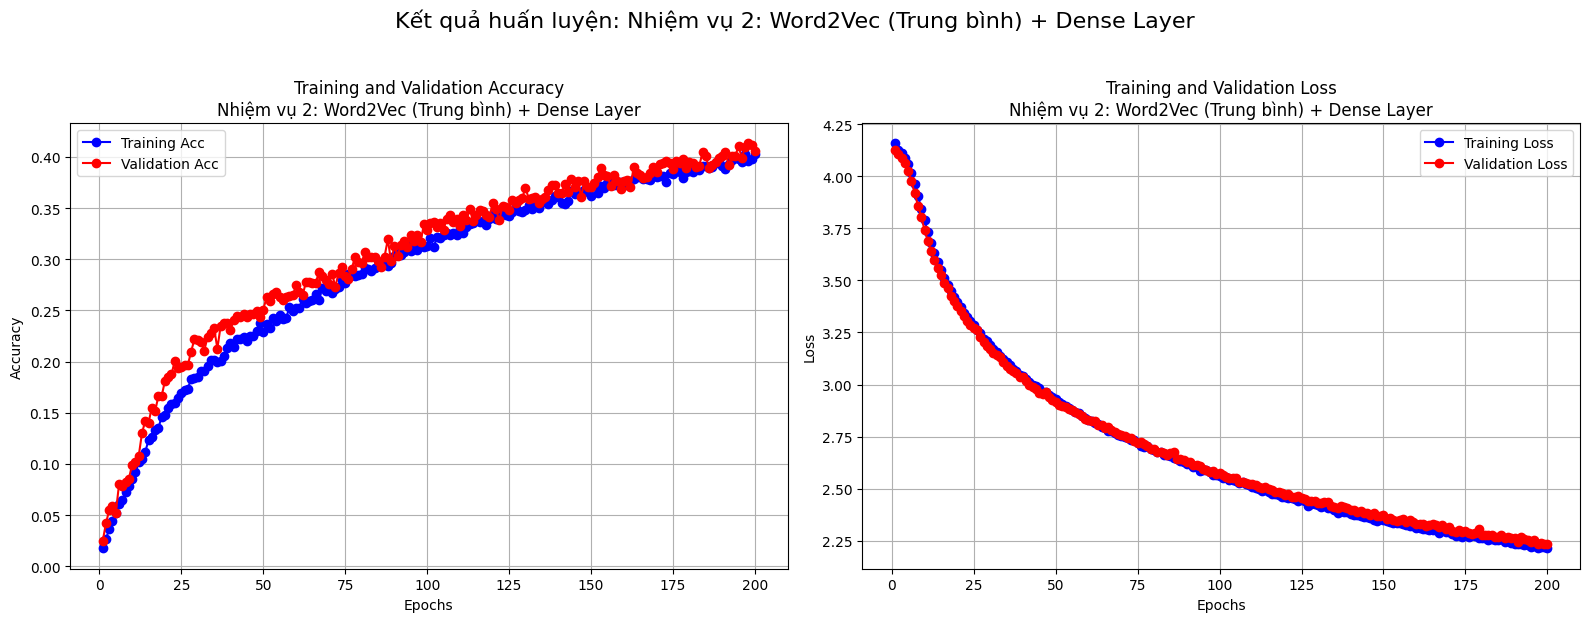

In [16]:
plot_history(history_avg_w2v, "Nhiệm vụ 2: Word2Vec (Trung bình) + Dense Layer")

**Vẽ biểu đồ Embedding Pre-trained + LSTM**

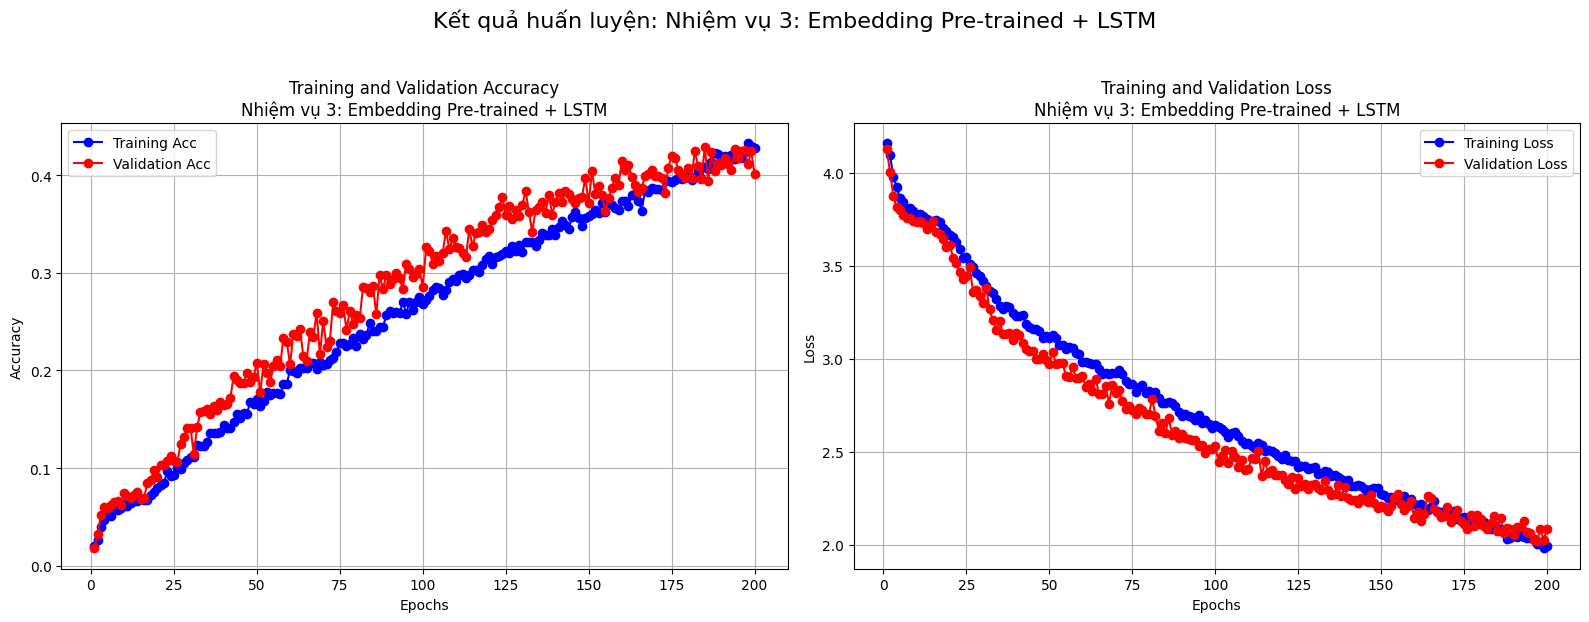

In [18]:
plot_history(history_pretrained, "Nhiệm vụ 3: Embedding Pre-trained + LSTM")

**Vẽ biểu đồ Embedding học từ đầu + LSTM**

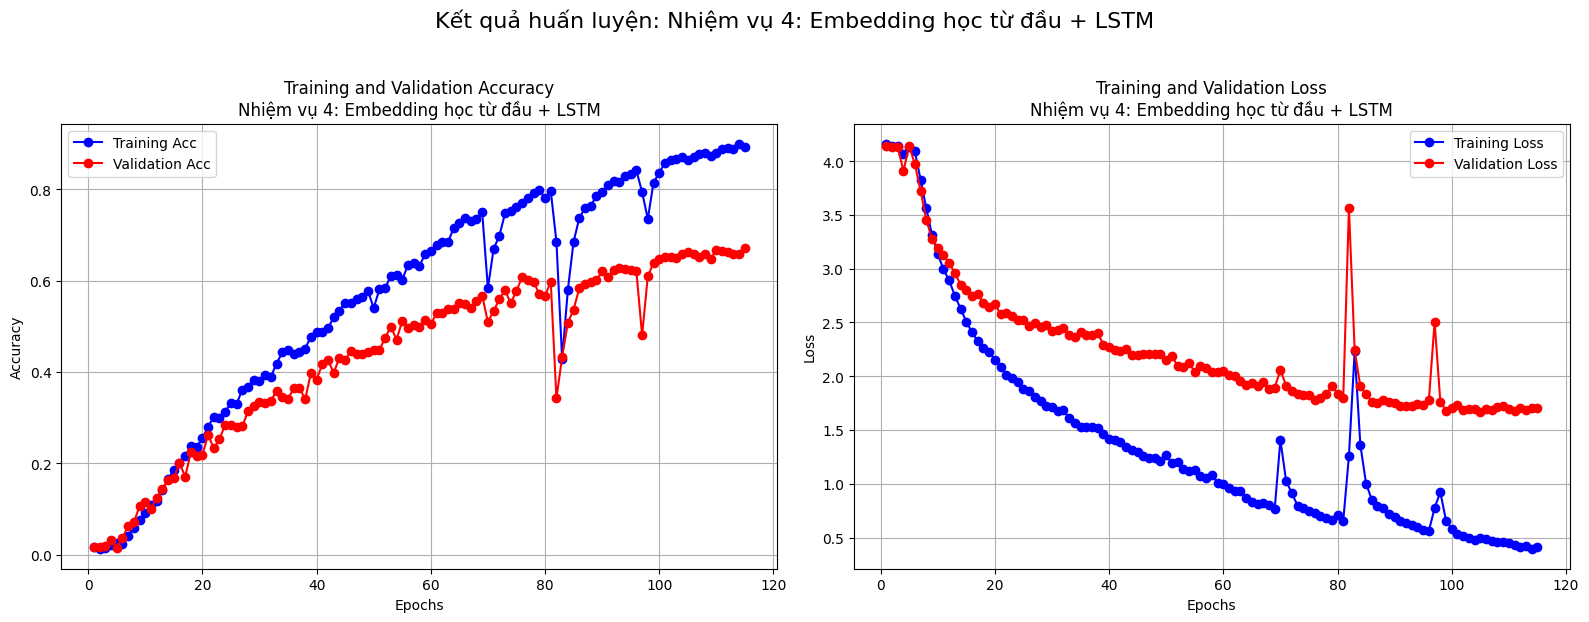

In [19]:
plot_history(history_scratch, "Nhiệm vụ 4: Embedding học từ đầu + LSTM")

## **2. Tính toán và Tổng hợp Các Chỉ số Định lượng**


In [28]:
import re
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# 1. Trích xuất F1-score macro average từ report_task1 (TF-IDF + Logistic Regression)
# report_task1 đã được tạo trong bước Nhiệm vụ 1 và là một chuỗi
# Tìm dòng 'macro avg' và trích xuất giá trị f1-score
match_lr = re.search(r"macro avg\s+\d\.\d{2}\s+\d\.\d{2}\s+(\d\.\d{2})", report_task1)
if match_lr:
    f1_lr = float(match_lr.group(1))
else:
    f1_lr = np.nan # Hoặc xử lý lỗi khác nếu không tìm thấy

# 2. Word2Vec (Trung bình) + Dense
y_pred_avg_w2v_proba = model_avg_w2v.predict(X_test_avg, verbose=0)
y_pred_avg_w2v = np.argmax(y_pred_avg_w2v_proba, axis=1)
report_avg_w2v = classification_report(y_test_encoded, y_pred_avg_w2v, output_dict=True)
f1_avg_w2v = report_avg_w2v['macro avg']['f1-score']

# 3. Embedding (Pre-trained) + LSTM
y_pred_pretrained_proba = lstm_model_pretrained.predict(X_test_pad, verbose=0)
y_pred_pretrained = np.argmax(y_pred_pretrained_proba, axis=1)
report_pretrained = classification_report(y_test_encoded, y_pred_pretrained, output_dict=True)
f1_pretrained = report_pretrained['macro avg']['f1-score']

# 4. Embedding (Học từ đầu) + LSTM
y_pred_scratch_proba = lstm_model_scratch.predict(X_test_pad, verbose=0)
y_pred_scratch = np.argmax(y_pred_scratch_proba, axis=1)
report_scratch = classification_report(y_test_encoded, y_pred_scratch, output_dict=True)
f1_scratch = report_scratch['macro avg']['f1-score']

# 5. Tổng hợp kết quả vào DataFrame
results = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'Word2Vec (Avg) + Dense',
        'Embedding (Pre-trained) + LSTM',
        'Embedding (Scratch) + LSTM'
    ],
    'F1-score (Macro Avg)': [
        f"{f1_lr:.4f}",
        f"{f1_avg_w2v:.4f}",
        f"{f1_pretrained:.4f}",
        f"{f1_scratch:.4f}"
    ],
    'Test Loss': [
        'N/A', # Logistic Regression không có khái niệm loss tương đương
        f"{loss:.4f}",
        f"{loss_pre:.4f}",
        f"{loss_scratch:.4f}"
    ]
})


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [29]:
print("\n--- Bảng Tổng hợp Kết quả Đánh giá Mô hình ---")
print(results.to_markdown(index=False))


--- Bảng Tổng hợp Kết quả Đánh giá Mô hình ---
| Model                          |   F1-score (Macro Avg) | Test Loss   |
|:-------------------------------|-----------------------:|:------------|
| TF-IDF + Logistic Regression   |                 0.82   | N/A         |
| Word2Vec (Avg) + Dense         |                 0.3514 | 2.2898      |
| Embedding (Pre-trained) + LSTM |                 0.3893 | 2.0520      |
| Embedding (Scratch) + LSTM     |                 0.6192 | 1.8378      |


## **3. Phân tích Định tính Các Câu Khó**


In [37]:
difficult_sentences = [
    "I don't want to set an alarm for tomorrow, cancel it.",
    "Is there no music playing right now?",
    "Remind me not to forget to buy milk.",
    "Turn off all the lights in the living room, except for the lamp.",
    "Tell me what you are not able to do."
]

expected_intents_str = [
    "alarm_remove",
    "music_query",
    "lists_createoradd",
    "iot_hue_lightoff",
    "general_quirky"
]

# Mã hóa các ý định mong đợi
expected_intents_encoded = label_encoder.transform(expected_intents_str)

print("Các câu khó và Ý định dự kiến được mã hóa:")
for i, sentence in enumerate(difficult_sentences):
    print(f"- '{sentence}' -> Ý định dự kiến: '{expected_intents_str[i]}' ({expected_intents_encoded[i]})")

Các câu khó và Ý định dự kiến được mã hóa:
- 'I don't want to set an alarm for tomorrow, cancel it.' -> Ý định dự kiến: 'alarm_remove' (1)
- 'Is there no music playing right now?' -> Ý định dự kiến: 'music_query' (40)
- 'Remind me not to forget to buy milk.' -> Ý định dự kiến: 'lists_createoradd' (36)
- 'Turn off all the lights in the living room, except for the lamp.' -> Ý định dự kiến: 'iot_hue_lightoff' (31)
- 'Tell me what you are not able to do.' -> Ý định dự kiến: 'general_quirky' (25)


1. Dự đoán cho TF-IDF + Logistic Regression

In [44]:
# 1a. Tiền xử lý các câu khó cho TF-IDF
X_difficult_tfidf = tfidf_lr_pipeline.named_steps['tfidfvectorizer'].transform(difficult_sentences)

# 1b. Dự đoán
y_pred_difficult_lr_encoded = tfidf_lr_pipeline.named_steps['logisticregression'].predict(X_difficult_tfidf)

# 1c. Chuyển đổi nhãn dự đoán ngược lại
y_pred_difficult_lr_str = label_encoder.inverse_transform(y_pred_difficult_lr_encoded)

# 1d. In ra kết quả
for i, sentence in enumerate(difficult_sentences):
    print(f"Câu: '{sentence}'")
    print(f"  Nhãn mong đợi: {expected_intents_str[i]} ({expected_intents_encoded[i]})")
    print(f"  Dự đoán: {y_pred_difficult_lr_str[i]} ({y_pred_difficult_lr_encoded[i]})")
    print("--------------------------------------------------")

Câu: 'I don't want to set an alarm for tomorrow, cancel it.'
  Nhãn mong đợi: alarm_remove (1)
  Dự đoán: alarm_set (2)
--------------------------------------------------
Câu: 'Is there no music playing right now?'
  Nhãn mong đợi: music_query (40)
  Dự đoán: music_query (40)
--------------------------------------------------
Câu: 'Remind me not to forget to buy milk.'
  Nhãn mong đợi: lists_createoradd (36)
  Dự đoán: calendar_set (8)
--------------------------------------------------
Câu: 'Turn off all the lights in the living room, except for the lamp.'
  Nhãn mong đợi: iot_hue_lightoff (31)
  Dự đoán: iot_hue_lightoff (31)
--------------------------------------------------
Câu: 'Tell me what you are not able to do.'
  Nhãn mong đợi: general_quirky (25)
  Dự đoán: general_quirky (25)
--------------------------------------------------


2. Dự đoán cho Word2Vec (Trung bình) + Dense Layer

In [42]:
# 2a. Tiền xử lý các câu khó cho Word2Vec (trung bình)
X_difficult_avg_w2v = np.array([sentence_to_avg_vector(text, w2v_model) for text in difficult_sentences])

# 2b. Dự đoán
y_pred_difficult_avg_w2v_proba = model_avg_w2v.predict(X_difficult_avg_w2v, verbose=0)
y_pred_difficult_avg_w2v_encoded = np.argmax(y_pred_difficult_avg_w2v_proba, axis=1)

# 2c. Chuyển đổi nhãn dự đoán ngược lại
y_pred_difficult_avg_w2v_str = label_encoder.inverse_transform(y_pred_difficult_avg_w2v_encoded)

# 2d. In ra kết quả
for i, sentence in enumerate(difficult_sentences):
    print(f"Câu: '{sentence}'")
    print(f"  Nhãn mong đợi: {expected_intents_str[i]} ({expected_intents_encoded[i]})")
    print(f"  Dự đoán: {y_pred_difficult_avg_w2v_str[i]} ({y_pred_difficult_avg_w2v_encoded[i]})")
    print("--------------------------------------------------")

Câu: 'I don't want to set an alarm for tomorrow, cancel it.'
  Nhãn mong đợi: alarm_remove (1)
  Dự đoán: alarm_set (2)
--------------------------------------------------
Câu: 'Is there no music playing right now?'
  Nhãn mong đợi: music_query (40)
  Dự đoán: general_dontcare (20)
--------------------------------------------------
Câu: 'Remind me not to forget to buy milk.'
  Nhãn mong đợi: lists_createoradd (36)
  Dự đoán: transport_query (60)
--------------------------------------------------
Câu: 'Turn off all the lights in the living room, except for the lamp.'
  Nhãn mong đợi: iot_hue_lightoff (31)
  Dự đoán: iot_hue_lightup (33)
--------------------------------------------------
Câu: 'Tell me what you are not able to do.'
  Nhãn mong đợi: general_quirky (25)
  Dự đoán: general_explain (21)
--------------------------------------------------


3. Dự đoán cho Embedding Pre-trained + LSTM

In [41]:
# 3a. Tiền xử lý các câu khó cho Embedding Pre-trained + LSTM
X_difficult_pretrained_pad = pad_sequences(tokenizer.texts_to_sequences(difficult_sentences), maxlen=max_len, padding='post', truncating='post')

# 3b. Dự đoán
y_pred_difficult_pretrained_proba = lstm_model_pretrained.predict(X_difficult_pretrained_pad, verbose=0)
y_pred_difficult_pretrained_encoded = np.argmax(y_pred_difficult_pretrained_proba, axis=1)

# 3c. Chuyển đổi nhãn dự đoán ngược lại
y_pred_difficult_pretrained_str = label_encoder.inverse_transform(y_pred_difficult_pretrained_encoded)

# 3d. In ra kết quả
for i, sentence in enumerate(difficult_sentences):
    print(f"Câu: '{sentence}'")
    print(f"  Nhãn mong đợi: {expected_intents_str[i]} ({expected_intents_encoded[i]})")
    print(f"  Dự đoán: {y_pred_difficult_pretrained_str[i]} ({y_pred_difficult_pretrained_encoded[i]})")
    print("--------------------------------------------------")

Câu: 'I don't want to set an alarm for tomorrow, cancel it.'
  Nhãn mong đợi: alarm_remove (1)
  Dự đoán: alarm_set (2)
--------------------------------------------------
Câu: 'Is there no music playing right now?'
  Nhãn mong đợi: music_query (40)
  Dự đoán: recommendation_events (53)
--------------------------------------------------
Câu: 'Remind me not to forget to buy milk.'
  Nhãn mong đợi: lists_createoradd (36)
  Dự đoán: cooking_recipe (10)
--------------------------------------------------
Câu: 'Turn off all the lights in the living room, except for the lamp.'
  Nhãn mong đợi: iot_hue_lightoff (31)
  Dự đoán: iot_hue_lightoff (31)
--------------------------------------------------
Câu: 'Tell me what you are not able to do.'
  Nhãn mong đợi: general_quirky (25)
  Dự đoán: music_query (40)
--------------------------------------------------


4. Dự đoán cho Embedding học từ đầu + LSTM

In [46]:
# 4a. Tiền xử lý các câu khó cho Embedding học từ đầu + LSTM
X_difficult_scratch_pad = pad_sequences(tokenizer.texts_to_sequences(difficult_sentences), maxlen=max_len, padding='post', truncating='post')

# 4b. Dự đoán
y_pred_difficult_scratch_proba = lstm_model_scratch.predict(X_difficult_scratch_pad, verbose=0)
y_pred_difficult_scratch_encoded = np.argmax(y_pred_difficult_scratch_proba, axis=1)

# 4c. Chuyển đổi nhãn dự đoán ngược lại
y_pred_difficult_scratch_str = label_encoder.inverse_transform(y_pred_difficult_scratch_encoded)

# 4d. In ra kết quả
for i, sentence in enumerate(difficult_sentences):
    print(f"Câu: '{sentence}'")
    print(f"  Nhãn mong đợi: {expected_intents_str[i]} ({expected_intents_encoded[i]})")
    print(f"  Dự đoán: {y_pred_difficult_scratch_str[i]} ({y_pred_difficult_scratch_encoded[i]})")
    print("--------------------------------------------------")

Câu: 'I don't want to set an alarm for tomorrow, cancel it.'
  Nhãn mong đợi: alarm_remove (1)
  Dự đoán: alarm_set (2)
--------------------------------------------------
Câu: 'Is there no music playing right now?'
  Nhãn mong đợi: music_query (40)
  Dự đoán: music_likeness (39)
--------------------------------------------------
Câu: 'Remind me not to forget to buy milk.'
  Nhãn mong đợi: lists_createoradd (36)
  Dự đoán: calendar_set (8)
--------------------------------------------------
Câu: 'Turn off all the lights in the living room, except for the lamp.'
  Nhãn mong đợi: iot_hue_lightoff (31)
  Dự đoán: iot_hue_lightoff (31)
--------------------------------------------------
Câu: 'Tell me what you are not able to do.'
  Nhãn mong đợi: general_quirky (25)
  Dự đoán: qa_stock (52)
--------------------------------------------------


### **Nhận xét**

**Kết quả Dự đoán:**

| Câu                                                              | Nhãn mong đợi        | TF-IDF + LR          | W2V (Avg) + Dense    | Emb (Pre-trained) + LSTM | Emb (Scratch) + LSTM |
|:-----------------------------------------------------------------|:--------------------|:---------------------|:---------------------|:-------------------------|:---------------------|
| "I don't want to set an alarm for tomorrow, cancel it."      | `alarm_remove`      | `alarm_set`          | `alarm_set`          | `alarm_set`              | `alarm_set`          |
| "Is there no music playing right now?"                       | `music_query`       | `music_query`        | `general_dontcare`   | `recommendation_events`  | `music_likeness`     |
| "Remind me not to forget to buy milk."                       | `lists_createoradd` | `calendar_set`       | `transport_query`    | `cooking_recipe`         | `calendar_set`       |
| "Turn off all the lights in the living room, except for the lamp." | `iot_hue_lightoff`  | `iot_hue_lightoff`   | `iot_hue_lightup`    | `iot_hue_lightoff`       | `iot_hue_lightoff`   |
| "Tell me what you are not able to do."                       | `general_quirky`    | `general_quirky`     | `general_explain`    | `music_query`            | `qa_stock`           |

**Phân tích:**

1.  **Câu 1: "I don't want to set an alarm for tomorrow, cancel it." (Phủ định + Hành động kép)**
    *   **Mong đợi:** `alarm_remove` (Hủy bỏ báo thức)
    *   **Dự đoán của tất cả các mô hình:** `alarm_set`
    *   **Nhận xét:** Tất cả các mô hình đều gặp khó khăn với câu này. Yếu tố "don't want to set" và "cancel it" rõ ràng chỉ ra `alarm_remove`, nhưng tất cả đều dự đoán `alarm_set`. Điều này cho thấy các mô hình, bao gồm cả LSTM, vẫn chưa hiểu được sắc thái của sự phủ định và mối quan hệ giữa các mệnh đề trong câu để đưa ra ý định chính xác. Có lẽ từ khóa "set an alarm" mạnh hơn các từ phủ định hoặc hủy bỏ.

2.  **Câu 2: "Is there no music playing right now?" (Phủ định + Câu hỏi)**
    *   **Mong đợi:** `music_query`
    *   **Dự đoán:**
        *   TF-IDF + LR: `music_query` (Chính xác)
        *   W2V (Avg) + Dense: `general_dontcare`
        *   Emb (Pre-trained) + LSTM: `recommendation_events`
        *   Emb (Scratch) + LSTM: `music_likeness`
    *   **Nhận xét:** TF-IDF + LR bất ngờ lại chính xác nhất ở đây. Các mô hình Word2Vec và LSTM đều không đúng. Điều này có thể do TF-IDF bắt được các từ khóa như "music" và "playing" mà không bị các từ phủ định như "no" làm nhiễu loạn quá nhiều, hoặc các mô hình dựa trên embedding đã bị ảnh hưởng bởi "no" và các từ xung quanh theo cách không mong muốn.

3.  **Câu 3: "Remind me not to forget to buy milk." (Phủ định + Ý định phức tạp)**
    *   **Mong đợi:** `lists_createoradd` (Thêm vào danh sách)
    *   **Dự đoán:**
        *   TF-IDF + LR: `calendar_set`
        *   W2V (Avg) + Dense: `transport_query`
        *   Emb (Pre-trained) + LSTM: `cooking_recipe`
        *   Emb (Scratch) + LSTM: `calendar_set`
    *   **Nhận xét:** Không có mô hình nào dự đoán chính xác. Ý định này phức tạp vì nó chứa "remind me" (có thể liên quan đến `calendar` hoặc `alarm`), "not to forget" (phủ định), và "buy milk" (liên quan đến `lists`). TF-IDF + LR và Emb (Scratch) + LSTM lại ra `calendar_set`, có lẽ do từ "remind". Các mô hình LSTM cũng cho thấy sự lẫn lộn giữa các ý định liên quan đến mua sắm/nấu ăn (`cooking_recipe`) hoặc tra cứu (`transport_query`).

4.  **Câu 4: "Turn off all the lights in the living room, except for the lamp." (Ngoại lệ + Điều khiển nhà thông minh)**
    *   **Mong đợi:** `iot_hue_lightoff`
    *   **Dự đoán:**
        *   TF-IDF + LR: `iot_hue_lightoff` (Chính xác)
        *   W2V (Avg) + Dense: `iot_hue_lightup`
        *   Emb (Pre-trained) + LSTM: `iot_hue_lightoff` (Chính xác)
        *   Emb (Scratch) + LSTM: `iot_hue_lightoff` (Chính xác)
    *   **Nhận xét:** Hầu hết các mô hình đều xử lý tốt câu này, ngoại trừ W2V (Avg) + Dense. Từ khóa "turn off" và "lights" đủ mạnh để dẫn đến dự đoán chính xác. Từ "except for the lamp" có thể là một yếu tố gây nhiễu, nhưng các mô hình LSTM và TF-IDF + LR đã bỏ qua nó hoặc hiểu ngữ cảnh tốt hơn. W2V (Avg) + Dense có thể đã bị ảnh hưởng bởi một số từ liên quan đến "light up" hoặc do tính trung bình hóa vector đã làm mất đi ngữ nghĩa quan trọng.

5.  **Câu 5: "Tell me what you are not able to do." (Trừu tượng + Phủ định)**
    *   **Mong đợi:** `general_quirky`
    *   **Dự đoán:**
        *   TF-IDF + LR: `general_quirky` (Chính xác)
        *   W2V (Avg) + Dense: `general_explain`
        *   Emb (Pre-trained) + LSTM: `music_query`
        *   Emb (Scratch) + LSTM: `qa_stock`
    *   **Nhận xét:** TF-IDF + LR lại một lần nữa đưa ra dự đoán chính xác. Các mô hình Embedding gặp khó khăn với câu hỏi trừu tượng này. Có vẻ như "general_quirky" là một nhãn khó học, và các mô hình có xu hướng đoán sang các loại câu hỏi chung chung khác (`general_explain`) hoặc thậm chí không liên quan (`music_query`, `qa_stock`).

**Tổng kết và Đánh giá khả năng xử lý chuỗi của LSTM:**

*   **TF-IDF + Logistic Regression:** Bất ngờ hoạt động rất tốt trên các câu khó này, đặc biệt là với các câu có yếu tố phủ định hoặc yêu cầu cụ thể. Điều này cho thấy TF-IDF có thể nắm bắt các từ khóa quan trọng và Logistic Regression có thể phân loại chúng hiệu quả, đôi khi tốt hơn các mô hình phức tạp hơn với lượng dữ liệu và ngữ cảnh này.

*   **Word2Vec (Trung bình) + Dense:** Cho thấy hiệu suất kém nhất trên các câu khó, điều này phù hợp với điểm số F1-score thấp nhất. Việc chỉ dùng vector trung bình có thể làm mất đi thông tin thứ tự từ và ngữ cảnh quan trọng, khiến mô hình khó hiểu các sắc thái phức tạp.

*   **Embedding (Pre-trained) + LSTM & Embedding (Scratch) + LSTM:** Mặc dù điểm F1-score tổng thể của LSTM (Scratch) cao hơn nhiều so với TF-IDF + LR, nhưng trên các câu khó, chúng lại không vượt trội hơn TF-IDF + LR. Cả hai mô hình LSTM đều gặp khó khăn với việc hiểu phủ định ("don't want", "no", "not to forget") và các cấu trúc phức tạp. Đặc biệt, câu 1 và 3 cho thấy LSTM chưa đủ khả năng để giải quyết sự phụ thuộc xa và các yếu tố ngữ nghĩa tinh tế liên quan đến phủ định hoặc ý định kép. Sự khác biệt giữa Embedding Pre-trained và học từ đầu không quá rõ ràng trên tập câu khó này, mặc dù model học từ đầu có điểm F1-score cao hơn đáng kể trên tập test tổng thể.

**Điểm mạnh của LSTM:** Chúng ta đã thấy LSTM (Scratch) đạt được F1-score cao nhất trên tập test tổng thể (0.6192), cho thấy khả năng của chúng trong việc học các mối quan hệ tuần tự và ngữ cảnh trong các câu bình thường. Tuy nhiên, trên các câu được thiết kế đặc biệt để kiểm tra khả năng hiểu phủ định và cấu trúc phức tạp, chúng vẫn còn hạn chế. Điều này có thể là do:

*   **Lượng dữ liệu:** Mặc dù có dữ liệu đủ dùng, các trường hợp phủ định hoặc phức tạp có thể không đủ phong phú trong tập huấn luyện để mô hình học được quy tắc tổng quát.
*   **Độ phức tạp của nhiệm vụ:** Phân tích ý định với các yếu tố phủ định hoặc cấu trúc ngôn ngữ khó là một nhiệm vụ phức tạp, đòi hỏi khả năng lý luận sâu hơn mà ngay cả các mô hình LSTM hiện tại cũng có thể gặp khó khăn.

**Kết luận:** Dựa trên phân tích các câu khó, TF-IDF + Logistic Regression thể hiện sự mạnh mẽ đáng ngạc nhiên trong một số trường hợp cụ thể. Các mô hình LSTM, mặc dù tốt hơn về hiệu suất tổng thể, vẫn cần cải thiện đáng kể trong việc xử lý các yếu tố phủ định và ngữ cảnh phức tạp. Điều này gợi ý rằng việc kết hợp các phương pháp khác (ví dụ: các mô hình Transformer, kỹ thuật tăng cường dữ liệu cho các trường hợp cạnh khóe, hoặc xử lý ngôn ngữ dựa trên luật) có thể là cần thiết để đạt được hiệu suất cao hơn trong các tình huống khó khăn.